# DQN CartPole Demo

This notebook is a thin debugging surface for the repo-native DQN workflow. The implementation lives in `model/rl_workflow.py`; this notebook only calls those functions.

In [11]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from model.rl_workflow import (
    evaluate_dqn,
    load_dqn_checkpoint,
    make_dqn_config,
    train_dqn,
)

print(ROOT)

c:\Users\ellio\OneDrive\Desktop\NN-kNN


## Smoke Run

Use the smoke profile for a quick end-to-end check. Switch to `fast` for the CartPole solve target.

In [ ]:
cfg = make_dqn_config("fast", seed=0)
state = train_dqn("cartpole", cfg, progress=True)
state["summary"]

[dqn] step=18 episode=1 return=18.0 length=18 epsilon=1.000 loss=None
[dqn] step=32 episode=2 return=14.0 length=14 epsilon=1.000 loss=None
[dqn] step=44 episode=3 return=12.0 length=12 epsilon=0.999 loss=None
[dqn] step=62 episode=4 return=18.0 length=18 epsilon=0.999 loss=None
[dqn] step=85 episode=5 return=23.0 length=23 epsilon=0.999 loss=None
[dqn] step=277 episode=10 return=17.0 length=17 epsilon=0.997 loss=None
[dqn] step=468 episode=20 return=13.0 length=13 epsilon=0.994 loss=None
[dqn] step=710 episode=30 return=13.0 length=13 epsilon=0.991 loss=None
[dqn] step=893 episode=40 return=13.0 length=13 epsilon=0.989 loss=None
[dqn] step=1102 episode=50 return=15.0 length=15 epsilon=0.986 loss=0.01441276166588068
[dqn] step=1325 episode=60 return=33.0 length=33 epsilon=0.983 loss=0.04596473276615143
[dqn] step=1538 episode=70 return=24.0 length=24 epsilon=0.981 loss=0.0743786171078682
[dqn] step=1788 episode=80 return=24.0 length=24 epsilon=0.977 loss=0.06167025491595268
[dqn] step=

{'task': 'cartpole',
 'env_id': 'CartPole-v1',
 'profile': 'fast',
 'seed': 0,
 'total_timesteps': 150000,
 'eval_episodes': 20,
 'success_threshold': 475.0,
 'passed': False,
 'final_eval': {'episodes': 20,
  'seed': 10000,
  'mean_return': 152.6999969482422,
  'std_return': 9.874715805053711,
  'min_return': 133.0,
  'max_return': 177.0,
  'mean_length': 152.6999969482422},
 'last_eval': {'episodes': 20,
  'seed': 10000,
  'mean_return': 118.75,
  'std_return': 3.284433126449585,
  'min_return': 113.0,
  'max_return': 126.0,
  'mean_length': 118.75},
 'selected_step': 135000,
 'selected_source': 'best_eval',
 'training_efficiency': {'best_model_step': 135000,
  'best_model_training_fraction': 0.9,
  'first_success_step': None,
  'first_success_training_fraction': None,
  'best_minus_last_return': 33.94999694824219,
  'budget_interpretation': 'unsolved_or_underfit'},
 'checkpoint_path': 'results\\rl\\dqn_cartpole_20260701_183004_199116\\checkpoint.pt',
 'run_dir': 'results\\rl\\dqn_ca

## Plot Episode Returns

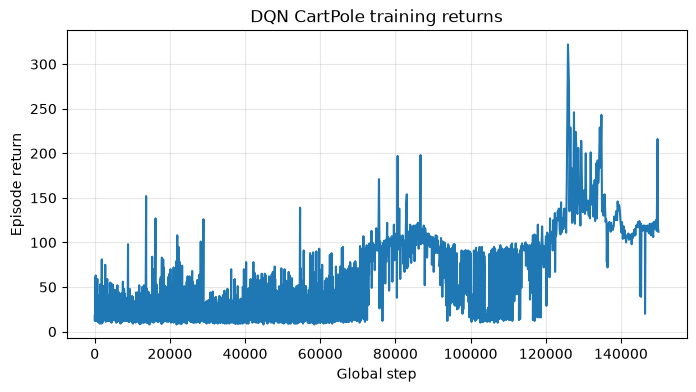

In [13]:
import csv
import matplotlib.pyplot as plt

run_dir = Path(state["run_dir"])
rows = []
with (run_dir / "training_metrics.csv").open(newline="", encoding="utf-8") as handle:
    for row in csv.DictReader(handle):
        rows.append(row)

steps = [int(row["global_step"]) for row in rows]
returns = [float(row["episode_return"]) for row in rows]

plt.figure(figsize=(8, 4))
plt.plot(steps, returns)
plt.xlabel("Global step")
plt.ylabel("Episode return")
plt.title("DQN CartPole training returns")
plt.grid(alpha=0.3)
plt.show()

## Reload And Evaluate

In [14]:
loaded = load_dqn_checkpoint(state["checkpoint_path"])
metrics = evaluate_dqn(
    loaded["task"]["name"],
    loaded["model"],
    episodes=cfg.eval_episodes,
    seed=cfg.eval_seed,
    device=loaded["device"],
)
{k: v for k, v in metrics.items() if k != "episode_metrics"}

{'episodes': 20,
 'seed': 10000,
 'mean_return': 152.6999969482422,
 'std_return': 9.874715805053711,
 'min_return': 133.0,
 'max_return': 177.0,
 'mean_length': 152.6999969482422}